<div align="center">

<h1> <b> CONSTANTE DE BOLTZMANN A PARTIR DE LA ECUACIÓN DE SHOCKLEY DEL DIODO </b> </h1>

</div>

<br>

<hr size=10 noshade color="green">
<p>
<p><img alt="UdeA logo" height="180px" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="left" hspace="100px" vspace="4px"></p>

<div align="right">       

<h3><i> <b>Cristian Vergara Restrepo <br>
Santiago Ramírez Gaviria</b> <br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

---


# Determinación de la constante de Boltzmann con la ecuación de diodo de Shockley

**Física Experimental IV**

## Objetivo general

Determinar el valor de la constante de Boltzmann a partir de mediciones de voltaje y corriente en un diodo semiconductor a temperatura conocida.

## Objetivos específicos

- Registrar curvas de corriente en función del voltaje para un diodo operado con dos resistencias de referencia distintas.
- Ajustar los datos experimentales a la ecuación de Shockley mediante regresión no lineal.
- A partir de los parámetros del ajuste, obtener un valor experimental de la constante de Boltzmann y compararlo con el valor de referencia de CODATA.

## Marco teórico

La ecuación de Shockley describe la corriente $I_D$ que circula a través de un diodo en función del voltaje $V_D$ aplicado sobre él:

$$
I_{D} = I_{S}(T) \left( e^{\frac{q \, V_{D}}{n \, k_{B} \, T}} - 1 \right)
$$

donde $I_S$ es la corriente de saturación inversa, $q$ es la carga del electrón, $n$ es el factor de idealidad del diodo, $k_B$ es la constante de Boltzmann y $T$ es la temperatura en Kelvin (Sze & Ng, 2007). El factor de idealidad $n$ típicamente toma valores entre 1 y 2, dependiendo de si el mecanismo de conducción dominante es la difusión de portadores o la recombinación en la región de carga espacial (Sze & Ng, 2007).

### Supuestos del experimento

1. **Temperatura constante:** se asume que la temperatura del diodo no varía apreciablemente durante la toma de datos, dado que los voltajes y corrientes empleados son bajos y el calentamiento óhmico resultante es mínimo.
2. **Medición de corriente y voltaje:** la corriente que circula por el diodo se mide mientras se varía el voltaje aplicado en incrementos controlados, usando dos resistencias de referencia distintas para obtener dos conjuntos de datos independientes.

### Procedimiento experimental

1. Se conecta el diodo en serie con una resistencia conocida y se aplica un voltaje variable al conjunto.
2. Se registran el voltaje $V_D$ a través del diodo y la corriente $I_D$ que circula por el circuito para distintos valores de voltaje aplicado, manteniendo la temperatura constante y conocida $T$.
3. Se repite el procedimiento con una segunda resistencia de referencia, para contar con dos conjuntos de datos independientes.

### Análisis de los datos

Los datos experimentales se ajustan a la ecuación de Shockley mediante regresión no lineal, dejando como parámetros libres la corriente de saturación $I_S$ y una combinación efectiva del factor de idealidad y la constante de Boltzmann. La temperatura $T$ y la carga del electrón $q$ se toman como constantes conocidas.

Nótese que, a una única temperatura fija, el modelo solo depende del producto $n\,k_B$ (a través del voltaje térmico efectivo $V_T = n\,k_B T/q$): dos combinaciones distintas de $n$ y $k_B$ que den el mismo producto son indistinguibles a partir de una sola curva $I$–$V$. Por esta razón, en este experimento se restringe $n$ a los dos valores enteros típicos (1 y 2) y se usa el valor de referencia de CODATA para la constante de Boltzmann como criterio para decidir cuál de los dos es consistente con los datos, en lugar de determinar $n$ y $k_B$ de manera totalmente independiente. El valor de $k_B$ que se reporta al final corresponde, por tanto, al que resulta de esa elección de $n$, más que a una medición completamente independiente de la constante.


## Desarrollo

### Ajuste de la ecuación de Shockley

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Constantes físicas conocidas
q = 1.602176634e-19    # Carga del electrón (C)
T = 299.15              # Temperatura del laboratorio (K)
k_codata = 1.380649e-23  # Constante de Boltzmann de referencia, CODATA (J/K)


In [2]:
# Datos experimentales: voltaje (V) y corriente (mA) medidos con dos
# resistencias de referencia distintas.

# Datos con R = 983 ohm
V1 = [0.2012, 0.2276, 0.2510, 0.2751, 0.2997, 0.3227, 0.3455, 0.3671, 0.3878, 0.406, 0.416, 0.432,
      0.441, 0.452, 0.468, 0.483, 0.491, 0.498, 0.505, 0.511, 0.516]
I1 = [0.2, 0.3, 0.6, 1.1, 1.7, 2.8, 4.5, 7.0, 10.6, 15.9, 23.0, 31.9, 42.3, 54.0, 67.9, 82.2,
      98.1, 114.5, 131.7, 149.3, 167.2]

# Datos con R = 326.9 ohm
V2 = [0.2011, 0.2264, 0.2514, 0.2757, 0.3007, 0.3242, 0.3481, 0.3715, 0.3942, 0.416, 0.436, 0.455,
      0.471, 0.486, 0.499, 0.510, 0.520, 0.528, 0.536, 0.543, 0.549]
I2 = [0.2, 0.4, 0.6, 1.1, 1.8, 2.9, 4.7, 7.6, 12.1, 19.3, 29.7, 44.7, 63.3, 86.8, 115.5,
      146.5, 182.4, 229.5, 260.3, 302.7, 346.1]


In [3]:
def best_approach(voltage, current, n_values=(1, 2), k_reference=k_codata):
    """Ajusta la ecuación de Shockley a los datos (voltage, current) para
    cada factor de idealidad n en `n_values`, dejando como parámetros
    libres la corriente de saturación I_s y el voltaje térmico efectivo
    V_t = n * k_B * T / q.

    Como el modelo solo depende del producto n * V_t, el ajuste tiene la
    misma calidad (mismo residual) sin importar qué n se asuma; por eso
    no es posible determinar n a partir de la bondad del ajuste. En su
    lugar, se usa `k_reference` (el valor de CODATA) para elegir, de los
    n propuestos, cuál da un valor de k_B más cercano al de referencia.

    Devuelve el factor de idealidad elegido N, la constante de Boltzmann
    recuperada k, la corriente de saturación I_s y sus incertidumbres
    (una desviación estándar), estimadas a partir de la matriz de
    covarianza del ajuste.
    """
    k_estimates = []
    is_estimates = []
    sig_k_estimates = []
    sig_is_estimates = []
    k_diff_to_reference = []

    for n in n_values:
        def shockley_eq(V, I_s, V_t):
            return I_s * (np.exp(V / (n * V_t)) - 1)

        popt, cov = curve_fit(shockley_eq, voltage, current)
        I_s, V_t = popt
        sig_I_s, sig_V_t = np.sqrt(np.diag(cov))

        # k_B = V_t * q / T, por definición de V_t = n * k_B * T / q
        k = V_t * q / T
        sig_k = sig_V_t * q / T

        k_estimates.append(k)
        is_estimates.append(I_s)
        sig_k_estimates.append(sig_k)
        sig_is_estimates.append(sig_I_s)
        k_diff_to_reference.append(abs(k_reference - k))

    best_index = int(np.argmin(k_diff_to_reference))
    N = n_values[best_index]
    return (N, k_estimates[best_index], is_estimates[best_index],
            sig_k_estimates[best_index], sig_is_estimates[best_index])


In [4]:
# Se determinan los mejores parámetros para cada conjunto de datos.
N1, k1, Is1, sig_k1, sig_Is1 = best_approach(V1, I1)
N2, k2, Is2, sig_k2, sig_Is2 = best_approach(V2, I2)

print(f"N1: {N1}, N2: {N2}")
print(f"k1: {k1:.4e} J/K, k2: {k2:.4e} J/K")
print(f"Is1: {Is1:.4e} mA, Is2: {Is2:.4e} mA")


N1: 2, N2: 2
k1: 1.3728e-23 J/K, k2: 1.2302e-23 J/K
Is1: 7.0013e-03 mA, Is2: 2.2402e-03 mA


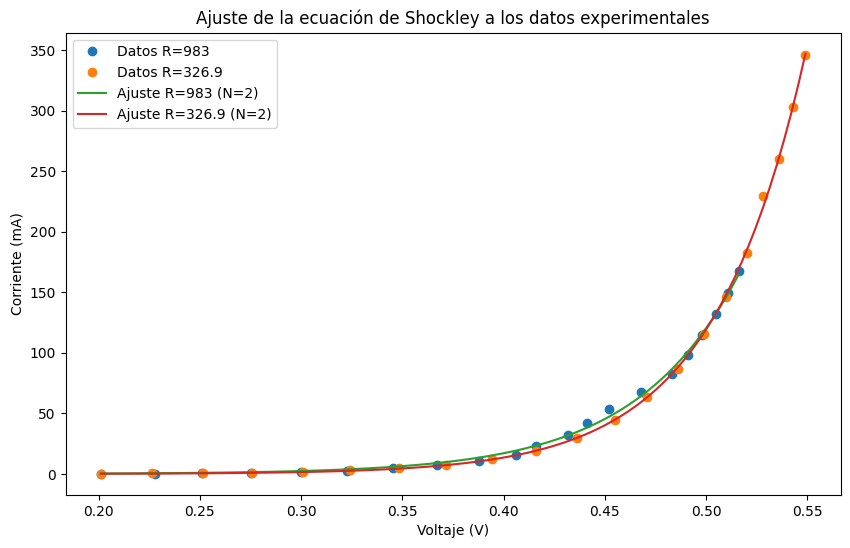

In [5]:
def shockley(V, I_s, n, k):
    """Corriente predicha por la ecuación de Shockley para el voltaje V,
    dados la corriente de saturación I_s, el factor de idealidad n y la
    constante de Boltzmann k, a la temperatura de laboratorio T."""
    return I_s * (np.exp(q * V / (n * k * T)) - 1)


x1 = np.linspace(np.min(V1), np.max(V1), 100)
y1 = shockley(x1, Is1, N1, k1)

x2 = np.linspace(np.min(V2), np.max(V2), 100)
y2 = shockley(x2, Is2, N2, k2)

plt.figure(figsize=(10, 6))
plt.plot(V1, I1, 'o', label='Datos R=983')
plt.plot(V2, I2, 'o', label='Datos R=326.9')
plt.plot(x1, y1, label=f'Ajuste R=983 (N={N1})')
plt.plot(x2, y2, label=f'Ajuste R=326.9 (N={N2})')
plt.xlabel('Voltaje (V)')
plt.ylabel('Corriente (mA)')
plt.legend()
plt.title('Ajuste de la ecuación de Shockley a los datos experimentales')
plt.show()


**Análisis**

1. **Determinación de parámetros:** utilizando la función `best_approach`, se ajustó la ecuación de Shockley para cada uno de los factores de idealidad propuestos ($n=1$ y $n=2$), y se seleccionó, para cada conjunto de datos, el que produce un valor de $k_B$ más cercano al de referencia de CODATA. Con esto se obtuvieron los siguientes resultados:

   Para los datos con $R = 983\,\Omega$:
   - $N_1 = 2$
   - $k_1 = 1.3728 \times 10^{-23}\, \text{J/K}$
   - $I_{s1} = 7.0013 \times 10^{-3}\, \text{mA}$

   Para los datos con $R = 326.9\,\Omega$:
   - $N_2 = 2$
   - $k_2 = 1.2302 \times 10^{-23}\, \text{J/K}$
   - $I_{s2} = 2.2402 \times 10^{-3}\, \text{mA}$

2. **Calidad del ajuste:** la ecuación de Shockley reproduce adecuadamente el comportamiento exponencial de los datos experimentales en ambos conjuntos, como se observa en la gráfica.

**Conclusiones**

1. Los valores de $k_1$ y $k_2$ obtenidos, del orden de $10^{-23}\,\text{J/K}$, son consistentes en orden de magnitud con el valor de referencia de CODATA ($1.380649\times10^{-23}\,\text{J/K}$), aunque presentan diferencias apreciables (entre 0.6 % y 11 % según el conjunto de datos).

2. Dado que, a una temperatura fija, el modelo de Shockley solo restringe el producto $n\,k_B$, este experimento no permite determinar $n$ y $k_B$ de manera completamente independiente: el factor de idealidad se fijó eligiendo, entre los valores típicos 1 y 2, el que da un $k_B$ más cercano al de CODATA. Por ello, los resultados deben interpretarse como una verificación de consistencia del modelo con un valor de $n=2$ para ambos conjuntos de datos, más que como una determinación independiente de la constante de Boltzmann. Una determinación verdaderamente independiente de $k_B$ y $n$ requeriría repetir las mediciones de corriente y voltaje a varias temperaturas conocidas.

3. La diferencia entre $k_1$ y $k_2$, obtenidos con dos resistencias de referencia distintas, da una idea del orden de magnitud de la incertidumbre experimental asociada al método, más allá de la incertidumbre estadística propia de cada ajuste individual.


---

## Referencias

- Bevington, P. R., & Robinson, D. K. (2003). *Data reduction and error analysis for the physical sciences* (3rd ed.). McGraw-Hill.
- Sze, S. M., & Ng, K. K. (2007). *Physics of semiconductor devices* (3rd ed.). Wiley-Interscience.